## K-Means 

### Segmentacion de clientes

In [3]:
#Importar las librerias
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans


In [4]:
# Crear el DataFrame
clientes = pd.DataFrame({"saldo":[50000,45000,48000,43500,47000,52000,20000,26000,
                                  25000,23000,21000,18000,8000,12000,6000,14500,12600,7000],
                        "transacciones":[25,20,16,23,25,18,23,22,24,21,27,19,8,3,6,4,9,3]})

In [5]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   saldo          18 non-null     int64
 1   transacciones  18 non-null     int64
dtypes: int64(2)
memory usage: 420.0 bytes


In [6]:
# Escalar los valores
escalador = MinMaxScaler().fit(clientes.values)

In [7]:
escalador

MinMaxScaler()

In [8]:
#Agregamos los valores escalados al dataframe
clientes = pd.DataFrame(escalador.transform(clientes.values), columns=["saldo","transacciones"])

In [9]:
clientes.head(5)

,saldo,transacciones
0,0.956522,0.916667
1,0.847826,0.708333
2,0.913043,0.541667
3,0.815217,0.833333
4,0.891304,0.916667


In [10]:
# Crear los numeros de cluster
kmeans = KMeans(n_clusters = 2).fit(clientes.values)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [11]:
# mostramos los numeros de grupos
kmeans.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

In [12]:
# Agregar las etiquetas a el dataframe
clientes["cluster"] = kmeans.labels_

In [13]:
clientes.head(5)

,saldo,transacciones,cluster
0,0.956522,0.916667,0
1,0.847826,0.708333,0
2,0.913043,0.541667,0
3,0.815217,0.833333,0
4,0.891304,0.916667,0


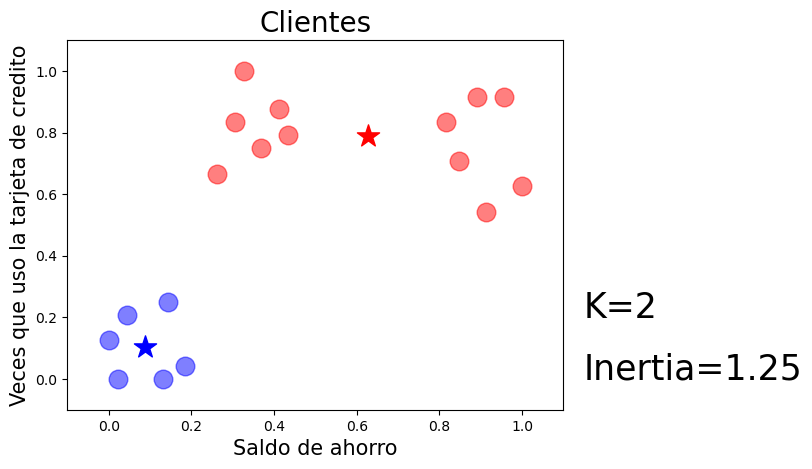

In [14]:
# Lista de colores para mostrar los grupos
colores = ["red","blue","orange","black","purple","pink","brown"]

# Para graficar los clousters
for cluster in range(kmeans.n_clusters):
    plt.scatter(clientes[clientes["cluster"]==cluster]["saldo"], # Obtubimos en el eje x el saldo en la cuenta de los clientes
                # "transacciones" Eje y representa el numero de transacciones con tarjeta de credito
                clientes[clientes["cluster"]==cluster]["transacciones"],
                marker="o", s=180, color=colores[cluster], alpha=0.5)
    
    plt.scatter(kmeans.cluster_centers_[cluster][0], # [cluster][0] Cordenada de x del centro cluster
                kmeans.cluster_centers_[cluster][1],# [cluster][1] Cordenada de y del centro cluster
                marker="*", 
                s=280, 
                color=colores[cluster]
               )

plt.title("Clientes", fontsize=20)
plt.xlabel("Saldo de ahorro", fontsize=15)
plt.ylabel("Veces que uso la tarjeta de credito", fontsize=15)

#Agrear un texto con el numero de clusters
plt.text(1.15,0.2,"K=%i" % kmeans.n_clusters, fontsize=25)
#Metrica que pide la calidad de clasificacion de los clusters

plt.text(1.15,0,"Inertia=%0.2f" % kmeans.inertia_, fontsize=25)

#Ajustar los limites del eje nx para que esten en rango entre 0 y 1
plt.xlim(-0.1,1.1)
plt.ylim(-0.1,1.1)

plt.show()


## Calcular el numero de Clusters(k)

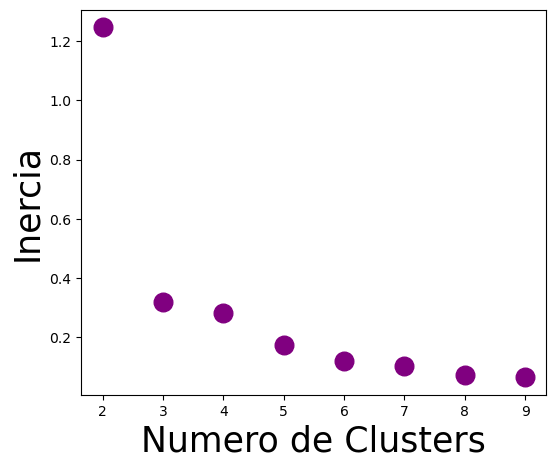

In [31]:
# Creamos una lista para guardar la inertia
import warnings
warnings.filterwarnings("ignore")
inercias = []
for k in range(2,10):
    kmeans = KMeans(n_clusters=k).fit(clientes.values)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(6,5), dpi=100)
plt.scatter(range(2,10),inercias,marker="o", s=180, color="purple")
plt.xlabel("Numero de Clusters", fontsize=25)
plt.ylabel("Inercia", fontsize=25)
plt.show()